### Import packages

In [1]:
%load_ext autoreload
%autoreload 2

#Import general libs you'll need
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

# Import functions from main
from main import ATL_AGG_CONFIG

# Import functions from the utils
from utils import readers, analysis, processing
from utils import plotter
from utils.create_las_swath import create_als_swath, transform_als_swath
from utils.datum_transforms import convert_3d_nad83_to_wgs84
from utils.datum_transforms import get_geoid_height



### Identify files



In [21]:
f_dir = '/home/ejg2736/dev/icesat2_topobathy/outputs/test_valid_hits_pqt3/'
f_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/outputs'

# f_list = os.listdir(f_dir)
f_list = [f for f in os.listdir(f_dir) if f.endswith('.pqt')]

df_list = []
for f in f_list:
    df = pd.read_parquet(os.path.join(f_dir,f))
    df['file_name'] = f
    if (len(df[df.target_class == 'ground']) > 8) &\
        (len(df[df.target_class == 'roof']) > 8) &\
        (np.max(df.dist_to_wall[df.target_class == 'ground']) < 9)  &\
        (np.min(df.dist_to_wall[df.target_class == 'roof']) > -9 ):

        df_list.append(df)
    else:
        print(f'Rejected {f}')

valid_df = pd.concat(df_list,ignore_index=True)




Rejected ATL03_20250914211615_00052902_007_01_gt2r_40594_entry_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt2r_163603_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt2r_251876_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt2l_147977_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt2l_341781_entry_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt2l_341781_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3r_68282_entry_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3r_68282_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3r_117771_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3r_192963_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3l_162359_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3l_308922_exit_target_ph.pqt
Rejected ATL03_20250914211615_00052902_007_01_gt3l_327621_exit_target_ph.pqt

In [22]:
np.unique(valid_df.file_name)

array(['ATL03_20231205162031_11862106_007_01_gt1r_347377_exit_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt1r_4849_entry_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt1r_5953_entry_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt2r_129628_exit_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt2r_174875_exit_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt2r_174887_entry_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt2r_18329_entry_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt3r_17690_exit_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt3r_273423_exit_target_ph.pqt',
       'ATL03_20231219033935_00052202_007_01_gt3r_33170_entry_target_ph.pqt',
       'ATL03_20240305115955_11862206_007_01_gt1l_229477_exit_target_ph.pqt',
       'ATL03_20240305115955_11862206_007_01_gt1l_350220_entry_target_ph.pqt',
       'ATL03_20240305115955_11862206_007_01_gt1r_175003_entry_ta

In [23]:
from utils.building_processing import compute_esf


esf_df = compute_esf(valid_df, min_dist=-15.0, max_dist=15.0, bin_size=2)

In [24]:
esf_df

target_class,distance_to_wall,building,ground,total_photons,esf_ratio
0,-14.0,0,0,0,NaN
1,-12.0,0,0,0,NaN
2,-10.0,0,90,90,0.000000
3,-8.0,58,212,270,0.214815
4,-6.0,110,309,419,0.262530
5,-4.0,162,392,554,0.292419
6,-2.0,252,304,556,0.453237
7,0.0,324,291,615,0.526829
8,2.0,343,257,600,0.571667
9,4.0,339,269,608,0.557566


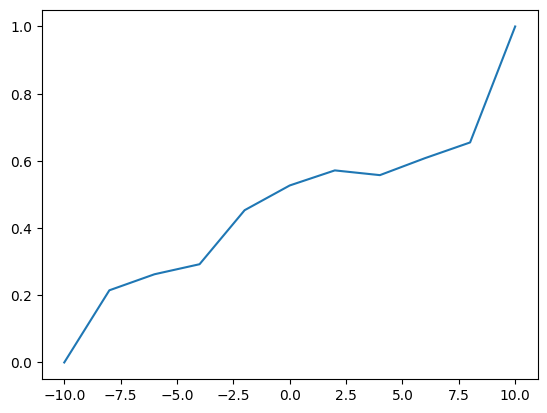

In [25]:
import matplotlib.pyplot as plt
plt.plot(esf_df.distance_to_wall,esf_df.esf_ratio)

In [ ]:
unique_files = np.unique(valid_df.file_name)

test_df = valid_df[valid_df.file_name == unique_files[12]]

plt.plot(test_df.dist_to_wall[test_df.target_class=='noise'],test_df.h_norm[test_df.target_class=='noise'],'.k')
plt.plot(test_df.dist_to_wall[test_df.target_class=='ground'],test_df.h_norm[test_df.target_class=='ground'],'.r')
plt.plot(test_df.dist_to_wall[test_df.target_class=='roof'],test_df.h_norm[test_df.target_class=='roof'],'.g')

IndexError: index 12 is out of bounds for axis 0 with size 5

In [ ]:
len(unique_files)

13

In [ ]:
unique_files[13]

'ATL03_20181215070448_11860106_007_01_gt2l_81083_exit_out.pqt'

In [ ]:
unique_files[0]

In [ ]:
unique_files[11]